In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import joblib

In [4]:
X_train = pd.read_csv("X_train_processed.xls")
X_test = pd.read_csv("X_test_processed.xls")

y_train = pd.read_csv("y_train.xls").squeeze()
y_test = pd.read_csv("y_test.xls").squeeze()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4000, 12)
X_test shape: (2000, 12)
y_train shape: (4000,)
y_test shape: (2000,)


In [5]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training class distribution:
Label
0    2000
1    2000
Name: count, dtype: int64

Testing class distribution:
Label
0    1000
1    1000
Name: count, dtype: int64


In [6]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

print("Logistic Regression model created.")

Logistic Regression model created.


In [7]:
model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [8]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions completed.")
print("Number of predictions:", len(y_pred))

Predictions completed.
Number of predictions: 2000


In [9]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Accuracy : 0.947
Precision: 0.9116
Recall   : 0.99
F1-Score : 0.9492
ROC-AUC  : 0.9858


In [10]:
print("Classification Report")
print("=" * 50)

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.90      0.94      1000
           1       0.91      0.99      0.95      1000

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



In [11]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[904  96]
 [ 10 990]]


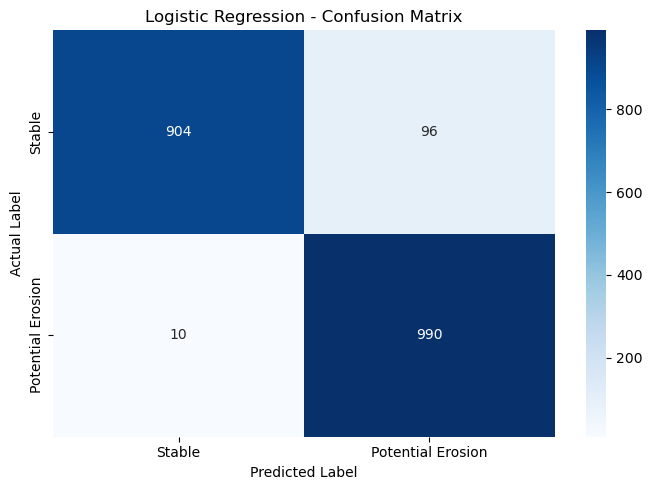

In [12]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stable", "Potential Erosion"],
    yticklabels=["Stable", "Potential Erosion"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

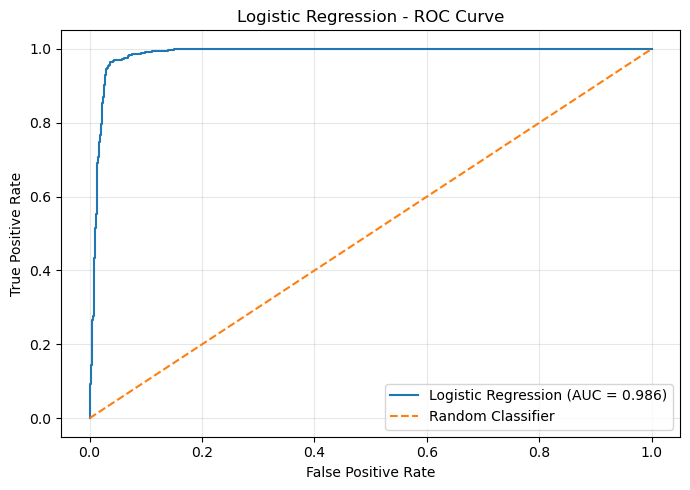

In [13]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression - ROC Curve")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

coefficients["Absolute_Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print(coefficients)

                         Feature  Coefficient  Absolute_Coefficient
4   numeric__Distance_From_River   -11.754529             11.754529
1                  numeric__NDWI    -3.401158              3.401158
5       categorical__LandCover_0     2.154697              2.154697
0                  numeric__NDVI    -1.858368              1.858368
9       categorical__LandCover_5    -1.660106              1.660106
10      categorical__LandCover_6    -0.941194              0.941194
6       categorical__LandCover_1    -0.856949              0.856949
11      categorical__LandCover_7     0.751022              0.751022
7       categorical__LandCover_3     0.734022              0.734022
2             numeric__Elevation    -0.625804              0.625804
8       categorical__LandCover_4    -0.442704              0.442704
3              numeric__Rainfall     0.236855              0.236855


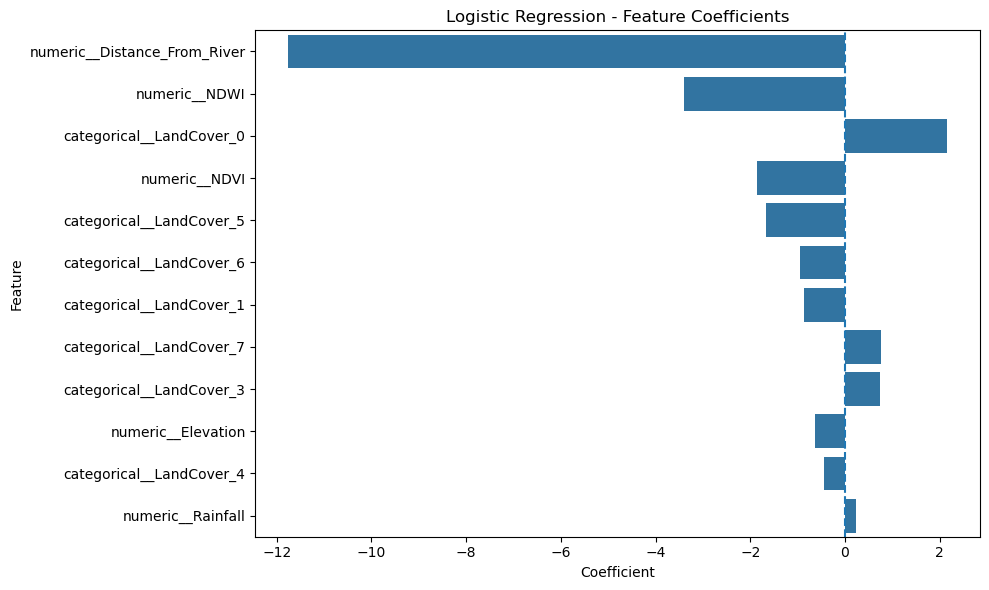

In [15]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Feature"
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Logistic Regression - Feature Coefficients"
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [16]:
results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1_Score": [f1],
    "ROC_AUC": [roc_auc]
})

print(results)

                 Model  Accuracy  Precision  Recall  F1_Score   ROC_AUC
0  Logistic Regression     0.947   0.911602    0.99  0.949185  0.985803


In [17]:
results.to_csv(
    "logistic_regression_results.csv",
    index=False
)

coefficients.to_csv(
    "logistic_regression_coefficients.csv",
    index=False
)

joblib.dump(
    model,
    "logistic_regression_model.pkl"
)

print("Logistic Regression model and results saved successfully.")

Logistic Regression model and results saved successfully.
